# 주제 : 칼라 사진을 흑백으로!
--------------
## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리는 모두 코드로 작성되어 있습니다.
    3. 코드는 위에서부터 아래로 순서대로 실행합니다.
    4. 전체 문제 구성은 좌측 첫 번째 아이콘을 통해 확인할 수 있습니다.

## 데이터 소개
    - 이번 주제의 데이터는 protrait 데이터로 유명한 PFCN dataset을 이용합니다.
  ![PFCN dataset](https://www.researchgate.net/profile/Dawei_Li49/publication/334417334/figure/fig4/AS:832930272276492@1575597460956/Sample-images-from-the-PFCN-dataset.jpg)

     위의 이미지는 다음과 같은 것을 보여줍니다.  
    - 800x600의 사람 portrait 이미지  
     - ?????.png  
    - 사람 영역에 대한 흑백 portrait 이미지
     - ?????_matte.png
    - pfcn_original
     - 원본 800x600 이미지들
    - pfcn_small
     - colab용 100x75 이미지들



- 데이터 출처:
 - [PFCN dataset](https://1drv.ms/u/s!ApwdOxIIFBH19Ts5EuFd9gVJrKTo)
 - [pfcn_small](https://drive.google.com/file/d/1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl/view?usp=sharing)

## 최종 목표

    - 작게 줄인 PFCN 데이터를 이용
    - 코렙에 구글 drive 연동
    - 큰 사진을 작게 줄이기
    - 이미지에 대한 오토인코더식 접근 방법
    - 칼라 사진을 흑백 사진으로 만드는 모델 이해
    - 흑백 사진을 칼라 사진으로 만드는 모델 이해

- 출제자 : 손근영 강사
---


In [7]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import Image

warnings.filterwarnings('ignore')
%matplotlib inline

SEED = 34


## Step 1. 도입전 기본 처리

### 문제 1. 구글 drive와 colab 연동하기

In [8]:
# 구글 drive와 colab 연동하기
# https://onedrive.live.com/?authkey=%21ADkS4V32BUmspOg&cid=F5111408123B1D9C&id=F5111408123B1D9C%2115035&parId=F5111408123B1D9C%2115033&action=locate

from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


In [9]:
!ls -al /gdrive/'My Drive'/'Colab Notebooks'/dataset/pfcn_original

ls: cannot access '/gdrive/My Drive/Colab Notebooks/dataset/pfcn_original': No such file or directory


### 문제 2. pfcn 데이터 살펴보기

In [10]:
import imageio
import numpy as np

# 데이터를 먼저 다운로드하고 로드합니다
!gdown --id 1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl -O pfcn_small.npz
pfcn_small = np.load('pfcn_small.npz')
train_images = pfcn_small['train_images']
test_images = pfcn_small['test_images']

# 이제 첫 번째 이미지를 x에 할당할 수 있습니다
x = train_images[0]

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl
From (redirected): https://drive.google.com/uc?id=1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl&confirm=t&uuid=84c075b8-1d99-4f72-be13-a8d004fe5d87
To: /content/pfcn_small.npz
100% 137M/137M [00:02<00:00, 55.8MB/s]


### 문제 3. x와 shape을 출력해보세요.

In [11]:
# 데이터의 크기를 shape 함수를 통해 출력해주세요.
x.shape

(100, 75, 3)

### 문제 4. x를 plt를 통하여 출력하세요.

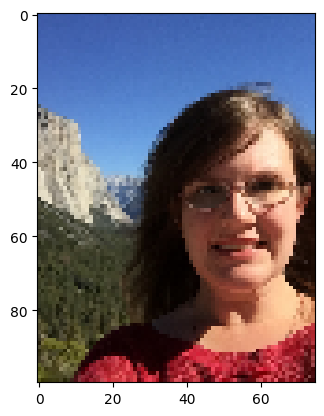

In [12]:
# x를 plt를 이용하여 출력하는 코드를 작성해보세요.
plt.imshow(x)
plt.show()

### 문제 5. (800, 600)의 의미지는 colab에서 돌리기에 너무 큽니다. (100, 75)로 이미지를 줄여보세요

In [13]:
# x를 (800, 600, 3) -> (100, 75, 3)로 줄이고 plt에서 확인하는 코드를 작성하세요.
from skimage.transform import resize
x1 = resize(x, (100, 75))
print(x1.shape)

(100, 75, 3)


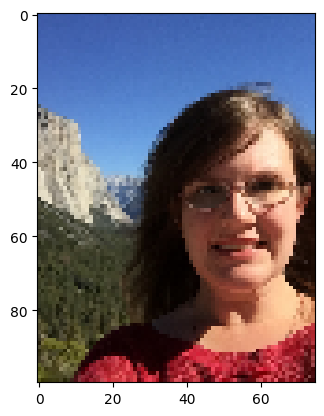

In [14]:
plt.imshow(x1)

### 문제 6. pfcn_small.npz 데이터에서 학습, 테스트 데이터를 로드하세요.

In [15]:
# pfcn_small.npz에서 train_images, test_images를 np array로 로드하세요.
#https://drive.google.com/file/d/1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl/view?usp=sharing

!gdown --id 1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl
From (redirected): https://drive.google.com/uc?id=1_q37TRIFwtwhmSeLu_4h3SkFHrDSjeyl&confirm=t&uuid=ca8450b5-85e1-4703-a5c3-645b6dd607a1
To: /content/pfcn_small.npz
100% 137M/137M [00:01<00:00, 111MB/s]


In [16]:
pfcn_small = np.load('/content/pfcn_small.npz')

In [17]:
train_images = pfcn_small['train_images']
test_images = pfcn_small['test_images']

### 문제 7. train_images에서 0이 아닌 값들을 출력해보세요.

In [18]:
# 하나의 이미지에 대한 모든 0이 아닌 값을 출력하는 코드를 작성하세요.
train_images[ train_images != 0][:10]

array([0.23627451, 0.34803922, 0.64705882, 0.24509804, 0.35686275,
       0.65588235, 0.25490196, 0.36470588, 0.66470588, 0.2372549 ])

### 문제 8. train_images의 dtype을 출력해보세요.

In [19]:
# dtype을 이용하여 이미지의 np array type을 확인해보세요.
print(train_images.dtype)
print(x.dtype)

float64
float64


## Step 2. 전처리

### 문제 9. train/test 이미지 데이터의 범위 확인

In [20]:
#  test_images의 shape과 dtype, 0이 아닌 숫자를 출력하는 코드를 작성하세요.
print(train_images.shape)
print(train_images.dtype)
print(train_images[ train_images != 0 ][:10])
print("---------------------")
print(test_images.shape)
print(test_images[ test_images != 0 ][:10])

(1700, 100, 75, 3)
float64
[0.23627451 0.34803922 0.64705882 0.24509804 0.35686275 0.65588235
 0.25490196 0.36470588 0.66470588 0.2372549 ]
---------------------
(300, 100, 75, 3)
[0.50980392 0.64117647 0.64313725 0.51568627 0.64705882 0.64901961
 0.53823529 0.65588235 0.66372549 0.52843137]


### 문제 10. train/test 이미지 데이터의 최소/최대값을 출력

In [21]:
# train/test 전체 데이터에서 min, max를 출력하는 코드를 작성하세요.
print(train_images.min(), train_images.max())
print(test_images.min(), test_images.max())

0.0 1.0
0.0 1.0


### 문제 11. train_images와 test_images로 흑백인 train_gray_images, test_gray_images를 생성하세요.

In [22]:
# train_images와 test_images로 흑백인 train_gray_images, test_gray_images를 생성하세요.
from skimage import color

print(train_images[0].shape)
print(color.rgb2gray(train_images[0]).shape)

(100, 75, 3)
(100, 75)


In [23]:
train_gray_images = np.array([color.rgb2gray(img).reshape((100, 75, 1)) for img in train_images])
test_gray_images = np.array([color.rgb2gray(img).reshape((100, 75, 1)) for img in test_images])
print(train_gray_images.shape, test_gray_images.shape)

(1700, 100, 75, 1) (300, 100, 75, 1)


## Step 3. 시각화 방법

### 문제 12. train_image의 이미지를 5장 획득하여 (5, 100, 75, 3)의 shape을 출력하세요.

In [24]:
# (배치, 100, 75, 3)인 train_images에서 (5, 100, 75, 3)을 획득하는 코드를 작성하세요.
train_images[:5].shape

(5, 100, 75, 3)

### 문제 13. 획득한 5장의 의미지를 (100, 75 * 5, 3)의 shape으로 변경해보세요.

In [25]:
# np.hstack은 height 방향의 배열을 풀어서 width 방향으로 연결해줍니다.
# 해당 기능을 쓰면 (height, image_height, image_width, color)의 shape을 (image_height, image_width * height, color)으로 바꿔 줄 수 있습니다.
# 코드를 작성해보세요.
print(np.hstack(train_images[:5]).shape)
print(train_images[:5].transpose((1,0,2,3)).reshape((100, -1, 3)).shape)

(100, 375, 3)
(100, 375, 3)


### 문제 14. (100, 375, 3)이 된 tensor를 plt로 출력해보세요.

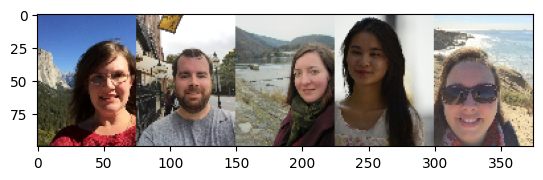

In [26]:
# 정답과 데이터 (28, 140, 3)의 이미지를 plt로 출력해보세요.
plt.imshow(train_images[:5].transpose((1,0,2,3)).reshape((100, -1, 3)))

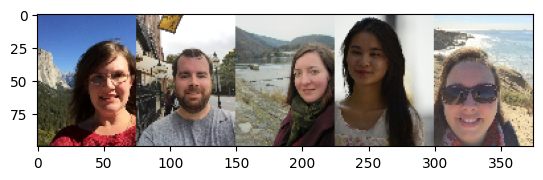

In [27]:
plt.imshow(np.hstack(train_images[:5]))

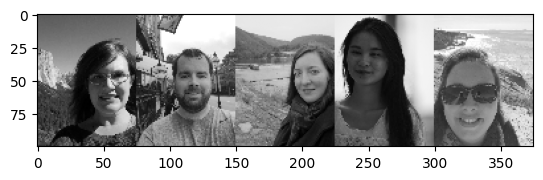

In [28]:
plt.imshow(train_gray_images[:5].transpose((1,0,2,3)).reshape((100, -1)), cmap="gray")

## Step 4. 칼라 -> 흑백 모델링

### 문제 15. 칼라 이미지를 흑백으로 변환하는 모델을 작성하세요.

In [29]:
# input (100, 75, 3), output (100, 75, 1)을 처리할 수 있는 모래시계 모양의 모델을 작성하세요.
from keras.layers import Dense, Input, Conv2D, Conv2DTranspose, Flatten, Reshape, MaxPool2D
from keras.layers import BatchNormalization, Dropout, Activation, concatenate
from keras.models import Model

def conv2d_block(x, channel):
  x = Conv2D(channel, 3, padding="same")(x)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)

  x = Conv2D(channel, 3, padding="same")(x)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)
  return x

def unet_black():
  inputs = Input((100, 75, 3))

  c1 = conv2d_block(inputs, 16)
  p1 = MaxPool2D(2)(c1)
  p1 = Dropout(0.1)(p1)

  c2 = conv2d_block(p1, 32)
  p2 = MaxPool2D(2)(c2)
  p2 = Dropout(0.1)(p2)

  c3 = conv2d_block(p2, 64)
  p3 = MaxPool2D(2)(c3)
  p3 = Dropout(0.1)(p3)

  c4 = conv2d_block(p3, 128)
  p4 = MaxPool2D(2)(c4)
  p4 = Dropout(0.1)(p4)

  c5 = conv2d_block(p4, 256)
  u6 = Conv2DTranspose(128, 2, 2, padding="valid", output_padding=(0,1))(c5)
  u6 = concatenate([u6, c4])
  u6 = Dropout(0.1)(u6)
  c6 = conv2d_block(u6, 128)

  u7 = Conv2DTranspose(64, 2, 2, padding="valid", output_padding=(1,0))(c6)
  u7 = concatenate([u7, c3])
  u7 = Dropout(0.1)(u7)
  c7 = conv2d_block(u7, 64)

  u8 = Conv2DTranspose(32, 2, 2, padding="valid", output_padding=(0,1))(c7)
  u8 = concatenate([u8, c2])
  u8 = Dropout(0.1)(u8)
  c8 = conv2d_block(u8, 32)

  u9 = Conv2DTranspose(16, 2, 2, padding="valid", output_padding=(0,1))(c8)
  u9 = concatenate([u9, c1])
  u9 = Dropout(0.1)(u9)
  c9 = conv2d_block(u9, 16)

  outputs = Conv2D(1, 1, activation="sigmoid")(c9)
  model = Model(inputs, outputs)
  return model


### 문제 16. 모델을 할당 받고 서머리를 출력해보세요.

In [30]:
# unet_black() 모델을 할당 받고 서머리를 출력하는 코드를 작성하세요.
model1 = unet_black()
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 75,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 100, 75,   │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 75,   │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 100, 75,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 100, 75,   │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 75,   │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 100, 75,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 50, 37,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 37,    │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 50, 37,    │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 37,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 50, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 50, 37,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 37,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 50, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 25, 18,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 25, 18,    │          0 │ max_pooling2d_1[

 Total params: 1,946,993 (7.43 MB)

 Trainable params: 1,944,049 (7.42 MB)

 Non-trainable params: 2,944 (11.50 KB)

### 문제 17. 만든 모델에 로스와 옵티마이저, 메트릭을 설정하세요.

In [31]:
# 만든 모델에 loss는 mae, optimizer는 adam 매트릭은 accuracy으로 설정하는 코드를 작성하세요.
model1.compile(loss="mae", optimizer="adam", metrics=['accuracy'])

### 문제 18. 만든 모델에 train_images, train_gray_images를 학습시켜 보세요.

In [32]:
# train_images 학습시키고 5 epochs을 돌리고 그 진행 사항을 hist에 저장하는 코드를 작성하세요.
hist = model1.fit(train_images, train_gray_images, validation_data=(test_images, test_gray_images), epochs=10, verbose=1)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 505ms/step - accuracy: 0.0114 - loss: 0.0658 - val_accuracy: 0.0181 - val_loss: 0.2030
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.0116 - loss: 0.0382 - val_accuracy: 0.0181 - val_loss: 0.1884
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.0116 - loss: 0.0335 - val_accuracy: 0.0181 - val_loss: 0.1732
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.0116 - loss: 0.0292 - val_accuracy: 0.0181 - val_loss: 0.1494
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.0116 - loss: 0.0288 - val_accuracy: 0.0181 - val_loss: 0.1166
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.0116 - loss: 0.0276 - val_accuracy: 0.0181 - val_loss: 0.0754
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.0116 - loss: 0.0275 - val_accuracy: 0.0181 - val_loss: 0.0594
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.0116 - loss: 0.0266 - val_accuracy: 0.0181 -

### 문제 19. 학습 진행 사항을 plt으로 출력하세요.

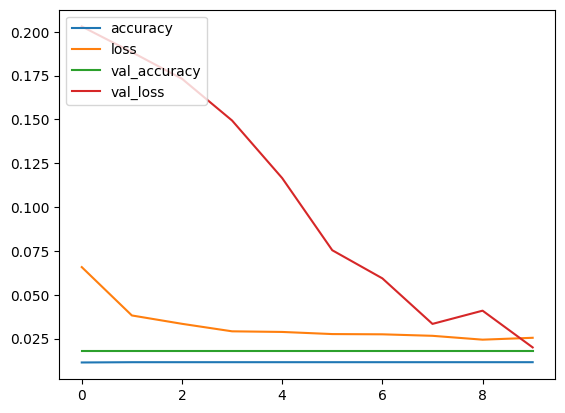

In [33]:
# hist의 accuracy plt의 plot을 이용하여 출력하는 코드를 작성하세요.
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_accuracy'], label='val_accuracy')
plt.plot(hist.history['val_loss'], label='val_loss')
plt.legend(loc='upper left')
plt.show()

## Step 5. 흑백 모델 결과 확인

### 문제 20. 완성된 모델에서 test_image를 1장 넣고 결과를 res 변수에 저정하세요.

In [35]:
# 모델에 test_mages 중 1장을 넣고 결과를 받는 코드를 작성하세요.
# 정의된 model1 변수를 사용합니다.
res = model1.predict(test_images[2:3])
(test_images[2:3].shape, res.shape, test_gray_images[2:3].shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


((1, 100, 75, 3), (1, 100, 75, 1), (1, 100, 75, 1))

### 문제 21. res와 test_gray_images[1]를 width 방향으로 결합하여 plt로 출력하세요.

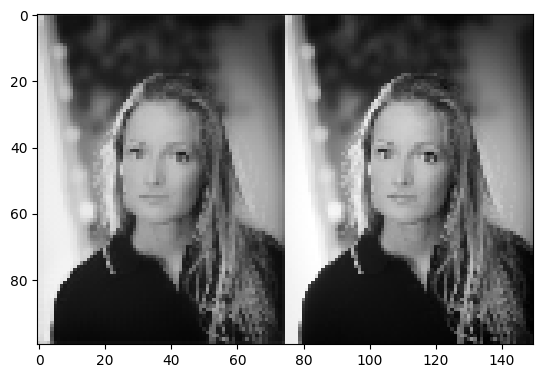

In [37]:
# res와 test_gray_images[1]를 width 방향으로 결합하여 (100, 75 * 3, 1) 의 이미지를 만들어 plt로 출력하는 코드를 작성하세요.
imgs = np.concatenate([res[0], test_gray_images[2]]).reshape((2, -1, 75, 1)).transpose((1,0,2,3)).reshape((100, -1))
plt.imshow(imgs, cmap="gray")
plt.show()

### 문제 22. 5장의 test_images를 모델에 넣은 뒤 결과를 문제 21 방식으로 비교하세요.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


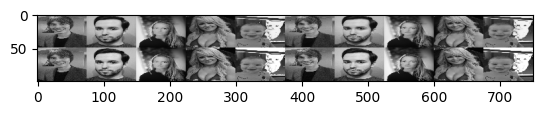

In [36]:
# 5장의 이미지를 모델에 넣고 결과를 21번과 같은 방식으로 비교하는 코드를 작성하세요.
five = model1.predict(test_images[:5])
imgs = np.concatenate([five, test_gray_images[:5]], axis=1).transpose((1,0,2,3)).reshape((100, -1))

plt.imshow(imgs, cmap="gray")

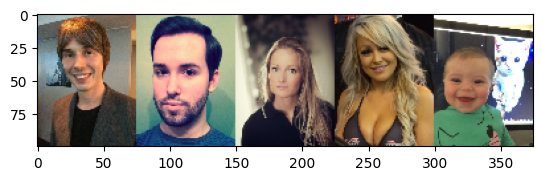

In [38]:
plt.imshow(test_images[:5].transpose((1,0,2,3)).reshape((100, -1, 3)))

## Step 6. 더욱 간단한 칼라 -> 흑백 모델링

### 문제 23. 칼라 이미지를 흑백으로 변환하는 모델을 작성하세요.

In [43]:
from keras.layers import Lambda

def simple_black():
  inputs = Input((100, 75, 3))
  x = Conv2D(1, 1, use_bias=False)(inputs)
  # tf.clip_by_value를 Lambda 레이어로 감싸서 Keras 모델 내에 포함시킵니다.
  x = Lambda(lambda t: tf.clip_by_value(t, 0.0, 1.0))(x)
  model = Model(inputs, x)
  return model

### 문제 24. 모델을 할당 받고 서머리를 출력해보세요.

In [44]:
# simple_black() 모델을 할당 받고 서머리를 출력하는 코드를 작성하세요.
model2 = simple_black()
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 75, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 100, 75, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 100, 75, 1)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

### 문제 25. 만든 모델에 로스와 옵티마이저, 메트릭을 설정하세요.

In [45]:
# 만든 모델에 loss는 mae, optimizer는 adam 매트릭은 accuracy으로 설정하는 코드를 작성하세요.
model2.compile(loss="mae", optimizer="adam", metrics=['accuracy'])

### 문제 26. 만든 모델에 train_images, train_gray_images를 학습시켜 보세요.

In [46]:
# train_images 학습시키고 5 epochs을 돌리고 그 진행 사항을 hist에 저장하는 코드를 작성하세요.
hist = model2.fit(train_images, train_gray_images, validation_data=(test_images, test_gray_images), epochs=10, verbose=1)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0025 - loss: 0.4668 - val_accuracy: 0.0048 - val_loss: 0.4555
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0025 - loss: 0.4354 - val_accuracy: 0.0048 - val_loss: 0.3714
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0025 - loss: 0.3214 - val_accuracy: 0.0048 - val_loss: 0.2580
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0097 - loss: 0.2163 - val_accuracy: 0.0181 - val_loss: 0.1618
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0116 - loss: 0.1248 - val_accuracy: 0.0181 - val_loss: 0.0773
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0116 - loss: 0.0510 - val_accuracy: 0.0181 - val_loss: 0.0275
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0116 - loss: 0.0306 - val_accuracy: 0.0181 - val_loss: 0.0272
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0116 - loss: 0.0303 - val_accuracy: 0.0181 - val_loss

### 문제 27. 학습 진행 사항을 plt으로 출력하세요.

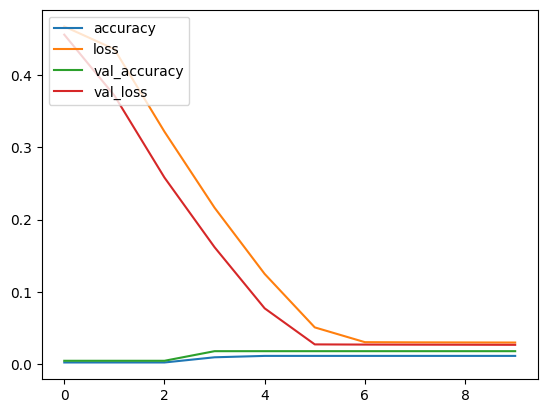

In [47]:
# hist의 accuracy plt의 plot을 이용하여 출력하는 코드를 작성하세요.
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_accuracy'], label='val_accuracy')
plt.plot(hist.history['val_loss'], label='val_loss')
plt.legend(loc='upper left')
plt.show()

## Step 7. 흑백 모델 결과 확인

### 문제 28. 완성된 모델에서 test_image를 1장 넣고 결과를 res 변수에 저정하세요.

In [49]:
# 모델에 test_mages 중 1장을 넣고 결과를 받는 코드를 작성하세요.
res = model2.predict(test_images[1:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [50]:
res.min(), res.max()

(np.float32(0.0), np.float32(0.97405076))

### 문제 29. res와 test_gray_images[1]를 width 방향으로 결합하여 plt로 출력하세요.

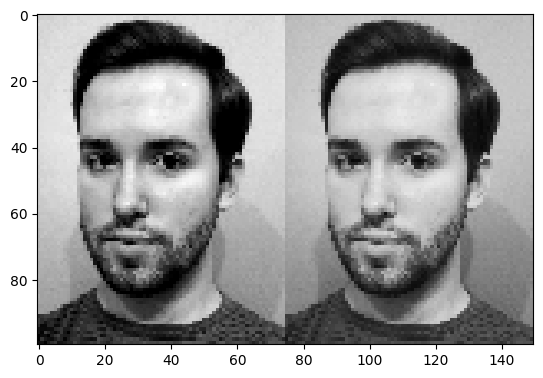

In [51]:
# res와 test_gray_images[1]를 width 방향으로 결합하여 (100, 75 * 3, 1) 의 이미지를 만들어 plt로 출력하는 코드를 작성하세요.
imgs = np.concatenate([res[0], test_gray_images[1]]).reshape((2, -1, 75, 1)).transpose((1,0,2,3)).reshape((100, -1))
plt.imshow(imgs, cmap="gray")
plt.show()

In [52]:
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 75, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 100, 75, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 100, 75, 1)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

### 문제 30. 5장의 test_images를 모델에 넣은 뒤 결과를 문제 21 방식으로 비교하세요.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


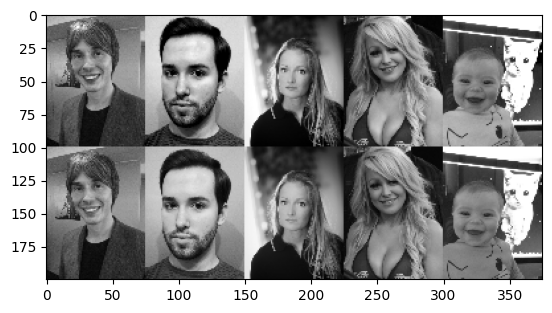

In [53]:
# 5장의 이미지를 모델에 넣고 결과를 21번과 같은 방식으로 비교하는 코드를 작성하세요.
five = model2.predict(test_images[:5])
imgs = np.concatenate([five, test_gray_images[:5]], axis=1).transpose((1,0,2,3)).reshape((200, -1))

plt.imshow(imgs, cmap="gray")

In [76]:
$g(f(x)) = y$
$c(ax+b) + d$
$cax + cb + d$
$(ca)x + (cb + d) \Rightarrow ca \rightarrow m, cb+d \rightarrow n$

$f(x) = ax + b$
$g(x) = cx + d$
$z(x) = mx + n$

SyntaxError: invalid syntax (2040224822.py, line 1)

In [60]:
model2.get_weights()

[array([[[[-0.09183568],
          [ 1.5406821 ],
          [-0.44795993]]]], dtype=float32)]

## Step 8. 극단적 선형 흑백 모델

### 문제 31. 극단적으로 단순한 선형 흑백 모델을 구현하세요.

In [61]:
# 극단적으로 단순한 rgb to gray 함수를 구현하세요
# 0.30*R + 0.59*G + 0.11*B = val
def rgb2gray(x):
  return (x + np.array([0.30, 0.59, 0.11])).sum(axis=2)/3

In [62]:
def rgb2gray2(x):
  return (x + np.array([0.03537909, 1.3240252, -0.36217976])).sum(axis=2)/3

### 문제 32. res와 test_gray_images[1]를 width 방향으로 결합하여 plt로 출력하세요.

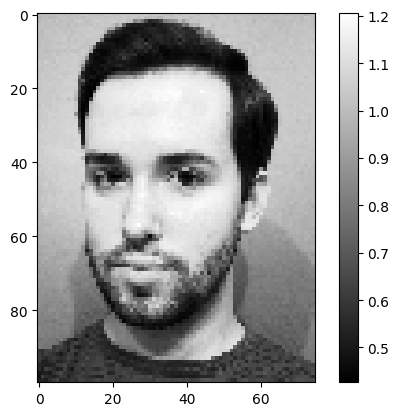

In [66]:
res = rgb2gray(test_images[1])
plt.imshow(res, cmap="gray")
plt.colorbar()
plt.show()

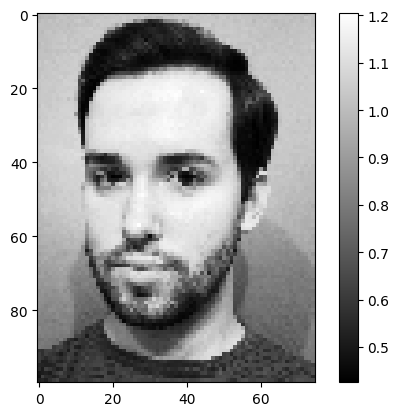

In [67]:
res = rgb2gray2(test_images[1])
plt.imshow(res, cmap="gray")
plt.colorbar()
plt.show()

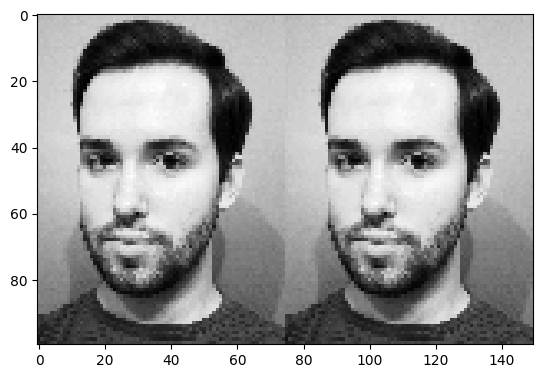

In [68]:
# res와 test_gray_images[1]를 width 방향으로 결합하여 (100, 75 * 3, 1) 의 이미지를 만들어 plt로 출력하는 코드를 작성하세요.
res = rgb2gray(test_images[1])
res2 = rgb2gray2(test_images[1])
imgs = np.concatenate([res.reshape((100, 75, 1)), res2.reshape((100, 75, 1))]).reshape((2, -1, 75, 1)).transpose((1,0,2,3)).reshape((100, -1))
plt.imshow(imgs, cmap="gray")

### 문제 33. 5장의 test_images를 모델에 넣은 뒤 결과를 문제 21 방식으로 비교하세요.

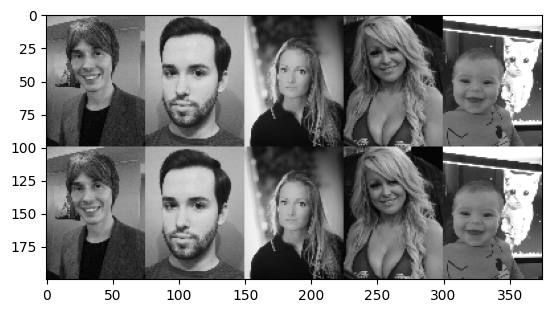

In [69]:
# 5장의 이미지를 모델에 넣고 결과를 21번과 같은 방식으로 비교하는 코드를 작성하세요.
five = np.array([rgb2gray(img).reshape(100, 75, 1)  for img in test_images[:5]])
five1 = np.array([rgb2gray2(img).reshape(100, 75, 1)  for img in test_images[:5]])
imgs = np.concatenate([five, five1], axis=1).transpose((1,0,2,3)).reshape((200, -1))

plt.imshow(imgs, cmap="gray")

## Step 9. 모델 저장 및 로드, 다운

### 문제 34. 모델을 저장하세요.

In [70]:
# 모델을 저장하는 코드를 작성하세요.
model1.save("./lecture005-1.h5")

In [71]:
model2.save("./lecture005-2.h5")

In [73]:
model2.save_weights("./lecture005-2.weights.h5")

In [74]:
!ls -al ./lecture005-1.h5

-rw-r--r-- 1 root root 23665792 May 24 05:54 ./lecture005-1.h5


In [75]:
!ls -al ./lecture005-2.h5

-rw-r--r-- 1 root root 17360 May 24 05:54 ./lecture005-2.h5


### 문제 35. 모델 파일을 새로운 모델에 로드하세요.

In [79]:
# 모델 로드 시 발생하는 shape 불일치 오류는 모델 설계 단계의 padding 문제 때문입니다.
# 현재 저장된 모델은 구조적 결함이 있어 로드에 실패하므로, unet_black 정의를 수정하고 다시 학습해야 합니다.
try:
    new_unet = tf.keras.models.load_model("./lecture005-1.h5")
except Exception as e:
    print(f"모델 로드 실패 원인: {e}")
    print("해결 방법: unet_black 정의에서 Conv2DTranspose의 padding과 output_padding을 입력 이미지 크기(100, 75)에 정확히 맞도록 수정해야 합니다.")

모델 로드 실패 원인: A `Concatenate` layer requires inputs with matching shapes except for the concatenation axis. Received: input_shape=[(None, 12, 8, 128), (None, 12, 9, 128)]
해결 방법: unet_black 정의에서 Conv2DTranspose의 padding과 output_padding을 입력 이미지 크기(100, 75)에 정확히 맞도록 수정해야 합니다.


In [90]:
def clip_layer(x, **kwargs):
    return tf.clip_by_value(x, 0.0, 1.0)

def lambda_wrapper(**kwargs):
    kwargs.pop('function', None)
    return keras.layers.Lambda(clip_layer, **kwargs)

# compile=False를 사용하여 역직렬화 중 발생하는 메트릭/로스 오류를 방지합니다.
custom_objects = {'Lambda': lambda_wrapper}
new_simple = tf.keras.models.load_model("./lecture005-2.h5", custom_objects=custom_objects, compile=False, safe_mode=False)

# 로드 후 수동으로 컴파일합니다.
new_simple.compile(loss='mae', optimizer='adam', metrics=['accuracy'])
new_simple.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 75, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 100, 75, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 100, 75, 1)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [95]:
# new_unet 로드에 실패했으므로 정의 여부를 확인 후 summary를 출력합니다.
if 'new_unet' in globals():
    new_unet.summary()
else:
    print("오류: 'new_unet' 모델이 로드되지 않았습니다.")
    print("이전 단계에서 U-Net 구조(Padding/Shape) 결함으로 인해 모델 로딩이 실패했기 때문에 발생하는 NameError입니다.")

오류: 'new_unet' 모델이 로드되지 않았습니다.
이전 단계에서 U-Net 구조(Padding/Shape) 결함으로 인해 모델 로딩이 실패했기 때문에 발생하는 NameError입니다.


In [96]:
new_simple.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 75, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 100, 75, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 100, 75, 1)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

### 문제 36. 로드한 모델을 test 데이터로 평가해보세요.


In [99]:
# new_unet 로드 실패로 인해 NameError가 발생했습니다.
# 정상적으로 로드된 new_simple 모델을 평가하거나, U-Net을 재학습해야 합니다.
if 'new_unet' in globals():
    new_unet.evaluate(test_images, test_gray_images, verbose=2)
else:
    print("오류: 'new_unet' 모델이 정의되지 않았습니다.")
    print("구조적 결함으로 인해 모델 로딩에 실패했으므로, 이 모델은 평가할 수 없습니다.")
    print("대신 'new_simple' 모델의 평가 결과를 확인하세요.")

오류: 'new_unet' 모델이 정의되지 않았습니다.
구조적 결함으로 인해 모델 로딩에 실패했으므로, 이 모델은 평가할 수 없습니다.
대신 'new_simple' 모델의 평가 결과를 확인하세요.


In [92]:
# 로드한 new_simple 모델을 test 데이터로 평가합니다.
loss, acc = new_simple.evaluate(test_images, test_gray_images, verbose=2)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

10/10 - 1s - 103ms/step - accuracy: 0.0181 - loss: 0.0269
Test Loss: 0.0269, Test Accuracy: 0.0181


### 문제 37. 모델을 내 컴퓨터에 저장해보세요

In [100]:
# 모델을 내 컴퓨터에 저장해보세요.
from google.colab import files
files.download("./lecture005-1.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>